In [1]:
import pandas as pd
import numpy as np
from collections import defaultdict, deque

np.random.seed(42)

# top1 strong labels: one MONDO term per GSE
human = pd.read_csv("results/human_strong_preds.csv")
mouse = pd.read_csv("results/mouse_strong_preds.csv")

print("Human:", human.shape)
print("Mouse:", mouse.shape)

print(human.columns.tolist())
print(mouse.columns.tolist())

# ontology info
cancer_terms = set(pd.read_csv("data/cancer_terms.csv")["mondo_id"])
edges_df = pd.read_csv("data/cancer_model_edges.csv")

ROOT = "MONDO_0004992"

parents = defaultdict(set)
children = defaultdict(set)

for _, row in edges_df.iterrows():
    child = row["child"]
    parent = row["parent"]
    if child in cancer_terms and parent in cancer_terms:
        parents[child].add(parent)
        children[parent].add(child)

# depth map
depth = {ROOT: 0}
queue = deque([ROOT])

while queue:
    current = queue.popleft()
    for ch in children.get(current, []):
        if ch not in depth:
            depth[ch] = depth[current] + 1
            queue.append(ch)

print("Max depth:", max(depth.values()))

Human: (1680, 5)
Mouse: (1257, 5)
['ID', 'mondo_id', 'prob', 'log2(prob/prior)', 'related_words']
['ID', 'mondo_id', 'prob', 'log2(prob/prior)', 'related_words']
Max depth: 7


In [2]:
def ancestors_with_depth(term):
    out = {}
    q = deque([(term, 0)])
    visited = {term}
    
    while q:
        node, dist = q.popleft()
        for p in parents.get(node, set()):
            if p not in visited:
                visited.add(p)
                out[p] = dist + 1
                q.append((p, dist + 1))
    return out

def lca_depth(term1, term2):
    anc1 = set(ancestors_with_depth(term1).keys()) | {term1}
    anc2 = set(ancestors_with_depth(term2).keys()) | {term2}
    common = anc1 & anc2
    if not common:
        return np.nan
    return max(depth.get(x, -1) for x in common)

def tree_distance(term1, term2):
    d1 = depth.get(term1, np.nan)
    d2 = depth.get(term2, np.nan)
    lca_d = lca_depth(term1, term2)
    if pd.isna(d1) or pd.isna(d2) or pd.isna(lca_d):
        return np.nan
    return d1 + d2 - 2 * lca_d

# keep cancer terms only
human_cancer = human[human["mondo_id"].isin(cancer_terms)].copy()
mouse_cancer = mouse[mouse["mondo_id"].isin(cancer_terms)].copy()

human_cancer["depth"] = human_cancer["mondo_id"].map(depth)
mouse_cancer["depth"] = mouse_cancer["mondo_id"].map(depth)

print("Human cancer:", human_cancer.shape)
print("Mouse cancer:", mouse_cancer.shape)

# matched pairs = same MONDO term
matched = human_cancer.merge(
    mouse_cancer,
    on="mondo_id",
    suffixes=("_human", "_mouse")
)

matched["pair_type"] = "matched"
print("Matched pairs:", matched.shape)

Human cancer: (554, 6)
Mouse cancer: (197, 6)
Matched pairs: (4161, 12)


In [3]:
# random pairs
n_random = len(matched)

human_idx = np.random.choice(human_cancer.index, size=n_random, replace=True)
mouse_idx = np.random.choice(mouse_cancer.index, size=n_random, replace=True)

random_pairs = pd.DataFrame({
    "ID_human": human_cancer.loc[human_idx, "ID"].values,
    "ID_mouse": mouse_cancer.loc[mouse_idx, "ID"].values,
    "mondo_id_human": human_cancer.loc[human_idx, "mondo_id"].values,
    "mondo_id_mouse": mouse_cancer.loc[mouse_idx, "mondo_id"].values,
    "score_human": human_cancer.loc[human_idx, "log2(prob/prior)"].values,
    "score_mouse": mouse_cancer.loc[mouse_idx, "log2(prob/prior)"].values,
    "pair_type": "random"
})

print("Random pairs:", random_pairs.shape)

# branch baseline: same depth, different MONDO term
mouse_by_depth = {d: df.copy() for d, df in mouse_cancer.groupby("depth")}

rows = []
for _, row in human_cancer.iterrows():
    h_id = row["ID"]
    h_term = row["mondo_id"]
    h_depth = row["depth"]
    h_score = row["log2(prob/prior)"]

    candidates = mouse_by_depth.get(h_depth, pd.DataFrame()).copy()
    if len(candidates) == 0:
        continue

    candidates = candidates[candidates["mondo_id"] != h_term]
    if len(candidates) == 0:
        continue

    picked = candidates.sample(1, random_state=np.random.randint(0, 10**6)).iloc[0]

    rows.append({
        "ID_human": h_id,
        "ID_mouse": picked["ID"],
        "mondo_id_human": h_term,
        "mondo_id_mouse": picked["mondo_id"],
        "score_human": h_score,
        "score_mouse": picked["log2(prob/prior)"],
        "pair_type": "branch"
    })

branch_pairs = pd.DataFrame(rows)
print("Branch pairs:", branch_pairs.shape)

matched_pairs = matched.rename(columns={
    "mondo_id": "mondo_id_human"
}).copy()

matched_pairs["mondo_id_mouse"] = matched_pairs["mondo_id_human"]
matched_pairs["score_human"] = matched_pairs["log2(prob/prior)_human"]
matched_pairs["score_mouse"] = matched_pairs["log2(prob/prior)_mouse"]

matched_pairs = matched_pairs[[
    "ID_human", "ID_mouse",
    "mondo_id_human", "mondo_id_mouse",
    "score_human", "score_mouse",
    "pair_type"
]].copy()

def add_ontology_distance(df):
    out = df.copy()
    out["depth_human"] = out["mondo_id_human"].map(depth)
    out["depth_mouse"] = out["mondo_id_mouse"].map(depth)
    out["lca_depth"] = [
        lca_depth(a, b)
        for a, b in zip(out["mondo_id_human"], out["mondo_id_mouse"])
    ]
    out["tree_distance"] = [
        tree_distance(a, b)
        for a, b in zip(out["mondo_id_human"], out["mondo_id_mouse"])
    ]
    return out

matched_dist = add_ontology_distance(matched_pairs)
random_dist = add_ontology_distance(random_pairs)
branch_dist = add_ontology_distance(branch_pairs)

Random pairs: (4161, 7)
Branch pairs: (554, 7)


Matched tree distance < Random p-value: 0.0
Matched tree distance < Branch p-value: 0.0


/tmp/ipykernel_2360545/1992886303.py:52: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(plot_data, labels=["Matched", "Random", "Branch"])


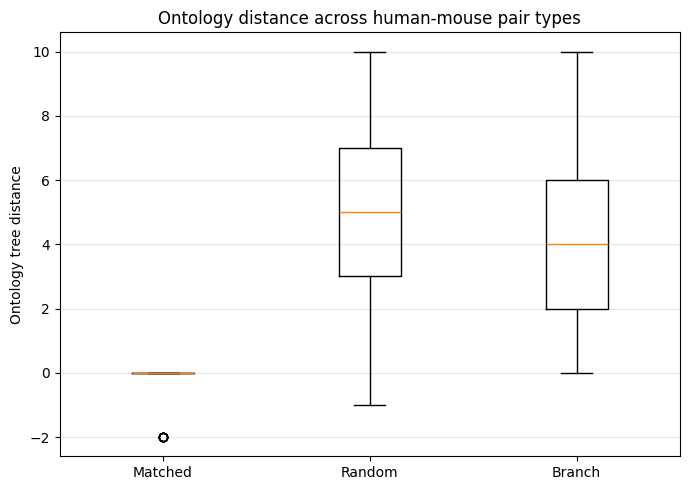

Saved ontology distance outputs.


In [4]:
summary = pd.DataFrame({
    "pair_type": ["matched", "random", "branch"],
    "n": [
        len(matched_dist),
        len(random_dist),
        len(branch_dist)
    ],
    "mean_tree_distance": [
        matched_dist["tree_distance"].mean(),
        random_dist["tree_distance"].mean(),
        branch_dist["tree_distance"].mean()
    ],
    "median_tree_distance": [
        matched_dist["tree_distance"].median(),
        random_dist["tree_distance"].median(),
        branch_dist["tree_distance"].median()
    ],
    "mean_lca_depth": [
        matched_dist["lca_depth"].mean(),
        random_dist["lca_depth"].mean(),
        branch_dist["lca_depth"].mean()
    ]
})

summary

from scipy.stats import mannwhitneyu

stat1, p1 = mannwhitneyu(
    matched_dist["tree_distance"].dropna(),
    random_dist["tree_distance"].dropna(),
    alternative="less"
)
print("Matched tree distance < Random p-value:", p1)

stat2, p2 = mannwhitneyu(
    matched_dist["tree_distance"].dropna(),
    branch_dist["tree_distance"].dropna(),
    alternative="less"
)
print("Matched tree distance < Branch p-value:", p2)

import matplotlib.pyplot as plt

plot_data = [
    matched_dist["tree_distance"].dropna(),
    random_dist["tree_distance"].dropna(),
    branch_dist["tree_distance"].dropna()
]

plt.figure(figsize=(7, 5))
plt.boxplot(plot_data, labels=["Matched", "Random", "Branch"])
plt.ylabel("Ontology tree distance")
plt.title("Ontology distance across human-mouse pair types")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

matched_dist.to_csv("results/matched_ontology_distance.csv", index=False)
random_dist.to_csv("results/random_ontology_distance.csv", index=False)
branch_dist.to_csv("results/branch_ontology_distance.csv", index=False)
summary.to_csv("results/ontology_distance_summary.csv", index=False)

print("Saved ontology distance outputs.")